1 Setup libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

2 Get file path

In [18]:

df = pd.read_json(r"C:\Users\ADMIN\Documents\Algorithm_Inno\ML\data\data_labeled.json") #You Must use your data path not mine
df.head()

,Transaction ID,Sender Account ID,Receiver Account ID,Transaction amount,Timestamp,Transaction Detail,Geological,Device Use,Gender,Location,Account balance,Transaction Count,Working Status,Salary (per month),Age,Balance_to_Salary_Ratio,Tx_to_Balance_Ratio,is_fraud,anomaly_score
0,TXN_300001,ACC_09194,REC_3448,0.087034,2025-12-28 08:59:00,5,2,0,2,3,0.262525,0,5,0.844444,0.463415,0.030553,0.000679,0,-0.513742
1,TXN_300001,ACC_09194,REC_3448,0.087034,2025-12-28 08:59:00,5,2,0,0,3,0.122244,0,0,0.933333,0.097561,0.013008,0.001451,0,-0.540757
2,TXN_300002,ACC_04160,REC_1969,0.766979,2025-05-27 14:30:00,2,0,1,0,6,0.971944,3,0,0.822222,0.317073,0.115758,0.001598,0,-0.527569
3,TXN_300003,ACC_00529,REC_8713,0.520959,2025-06-12 21:53:00,6,1,3,1,4,0.378758,4,4,0.933333,0.414634,0.040302,0.002784,0,-0.479995
4,TXN_300004,ACC_05993,REC_2068,0.096763,2025-06-11 14:34:00,3,2,1,0,4,0.454910,3,1,0.311111,0.756098,0.120053,0.000435,0,-0.471705


3 Pick features

In [19]:

feature_columns = [
    'Transaction amount', 'Account balance', 'Salary (per month)',
    'Hour', 'DayOfWeek', 'Age', 'Is_Weekend', 'Is_Night',
    'Balance_to_Salary_Ratio', 'Tx_to_Balance_Ratio',
    'Transaction Detail', 'Geological', 'Device Use', 
    'Location', 'Working Status', 'Gender', 'Transaction Count'
]

available = [col for col in feature_columns if col in df.columns]
X = df[available].copy()
y = df['is_fraud']

5 Train model

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


6 Evaluate

In [21]:
predictions = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, predictions):.2%}")
print(classification_report(y_test, predictions, target_names=['Normal', 'Fraud']))


Accuracy: 93.32%
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96      4850
       Fraud       0.89      0.62      0.73       839

    accuracy                           0.93      5689
   macro avg       0.91      0.81      0.85      5689
weighted avg       0.93      0.93      0.93      5689



7 Show importances impact to Detection 

In [ ]:
importance_df = pd.DataFrame({
    'Features': X.columns,  
    'Importances': model.feature_importances_
}).sort_values('Importances', ascending=False)

print(importance_df.head(5).to_string(index=False))


               Features  Importances
Balance_to_Salary_Ratio     0.192541
    Tx_to_Balance_Ratio     0.161912
        Account balance     0.121453
     Salary (per month)     0.105455
     Transaction amount     0.082011


8 Visualization


8.1 Feature Importance Bar Chart (most important)
    Visualize top 5 importance

Text(0.5, 0, 'Importance Score')

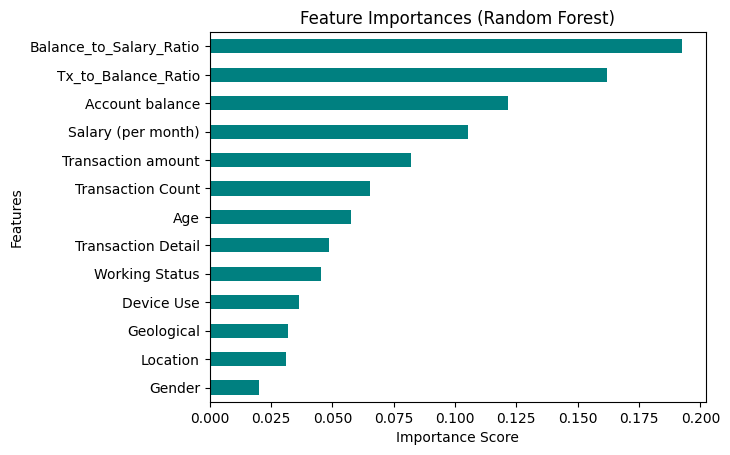

In [24]:
import matplotlib.pyplot as plt

importance_df.sort_values('Importances').plot(kind='barh', x='Features', y='Importances', legend=False, color='teal')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Importance Score')

5.2 Confusion Matrix
    Shows true positives, false positives, etc. — critical for fraud detection where false negatives are costly.

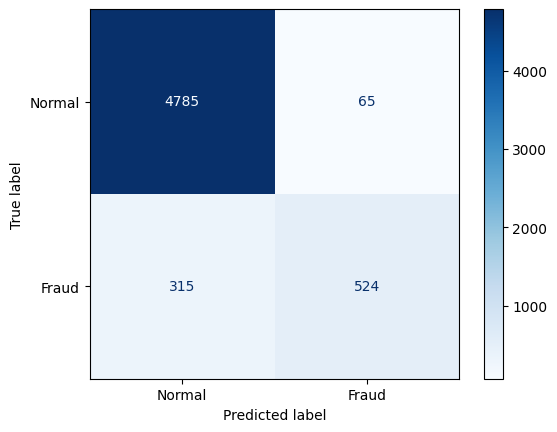

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, predictions, display_labels=['Normal','Fraud'], cmap='Blues')

3. ROC Curve
Visualizes the trade-off between catching fraud (recall) vs. false alarms (false positive rate).

Text(0.5, 1.0, 'ROC Curve - Random Forest')

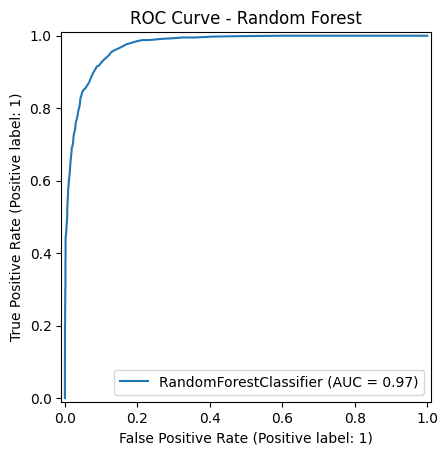

In [26]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('ROC Curve - Random Forest')

4. Precision-Recall Curve
More informative than ROC for imbalanced datasets like fraud detection (few fraud vs many normal).

Text(0.5, 1.0, 'Precision-Recall Curve')

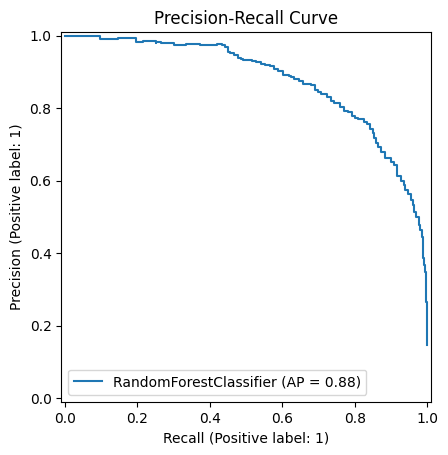

In [27]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(model, X_test, y_test)
plt.title('Precision-Recall Curve')

5. Single Tree Visualization (optional/impressive)
Visualize one of the 100 trees to understand decision logic.

[Text(0.5, 0.9, 'DayOfWeek <= 0.373\ngini = 0.261\nsamples = 14435\nvalue = [19249, 3503]\nclass = Normal'),
 Text(0.25, 0.7, 'Age <= 0.026\ngini = 0.208\nsamples = 13517\nvalue = [18744, 2511]\nclass = Normal'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'Device Use <= 5.5\ngini = 0.161\nsamples = 12984\nvalue = [18584, 1803]\nclass = Normal'),
 Text(0.0625, 0.3, 'Account balance <= 0.105\ngini = 0.137\nsamples = 12396\nvalue = [18027, 1442]\nclass = Normal'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'Is_Night <= 0.5\ngini = 0.477\nsamples = 588\nvalue = [557, 361]\nclass = Normal'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'Is_Weekend <= 0.5\ngini = 0.301\nsamples = 533\nvalue = [160, 708]\nclass = Fraud'),
 Text(0.3125, 0.3, 'Salary (per month) <= 0.411\ngini = 0.083\nsamples = 73\nvalue = [5, 110]\nclass = Fraud'),
 Text(0.28125, 0.1, '\n  (...)  \n'),
 Text(0.34375, 0.1, 

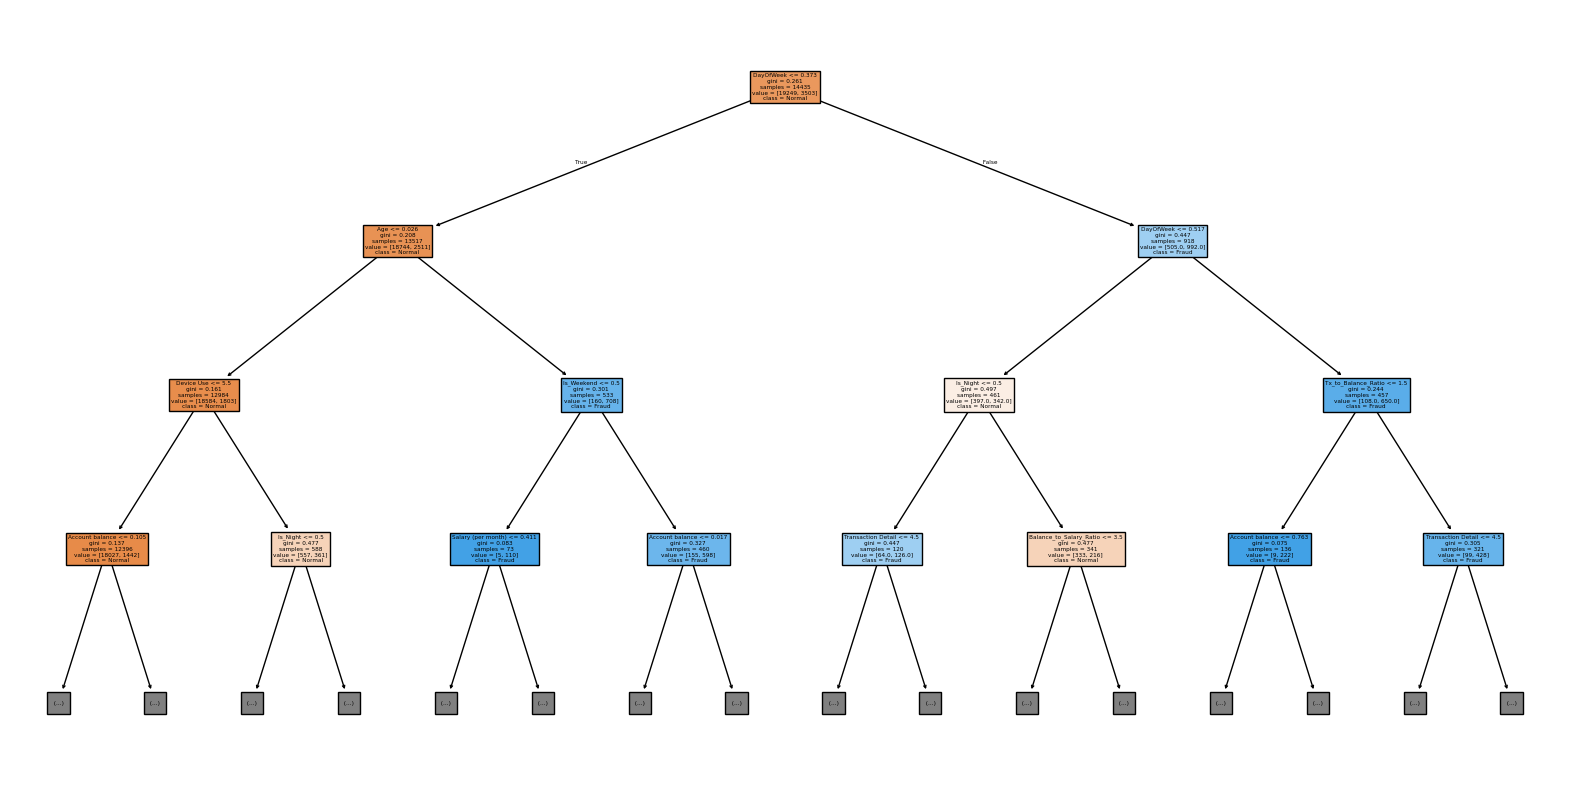

In [28]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(model.estimators_[0], feature_names=feature_columns, class_names=['Normal','Fraud'], max_depth=3, filled=True)